In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor


In [2]:
data_4=pd.read_csv('Modelling.csv')

## Modelling

In [3]:
cols = ['No_of_years','Age',
       'Postural instability present at dx?','Rigidity present at diagnosis?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'lightheaded after standing', 'fainted',
        'Total Depression Score', 'able_weighted_score','MDS-UPDRS Part I Score',
    'BMI','Daytime_Sleepiness', 'Urinary_Problems',
       'Gait', 'Postural_Stability', 'Hoehn_And_Yahr_Stage', 'Postural_hypotension','MDS-UPDRS Part III Score',
    'MDS-UPDRS PartIV score'
]

X = data_4[cols]
Y = data_4['Falls not rel to freezing past 36 months']
patient_ids = data_4['PATNO']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, Y, patient_ids, test_size = 0.3, random_state = 42, stratify=Y
)

In [4]:
# --------------------------------------------------
# Stage targets derived from the shared 70/30 split
# (used by the Stage 1 comparison and the full pipeline)
#   Stage 1: 0 = no fall vs 1 = any fall
#   Stage 2: among true fallers (1,2): mild (1) -> 0, moderate (2) -> 1
# --------------------------------------------------
y_train_s1 = (y_train != 0).astype(int)
y_test_s1  = (y_test  != 0).astype(int)

_fallers_train = y_train.isin([1, 2])
X_train_12 = X_train.loc[_fallers_train]
y_train_s2 = (y_train.loc[_fallers_train] == 2).astype(int)

print("Stage 1 train balance:", y_train_s1.value_counts().to_dict())
print("Stage 2 train balance:", y_train_s2.value_counts().to_dict(),
      f"(on {len(X_train_12)} fallers)")

Stage 1 train balance: {0: 504, 1: 313}
Stage 2 train balance: {0: 223, 1: 90} (on 313 fallers)


## Stage 1: Model Comparison

Tuning Logistic Regression...


  Best params: {'clf__C': 0.01, 'clf__solver': 'lbfgs'}
Tuning LinearSVC...
  Best params: {'estimator__clf__C': 0.01}
Tuning Random Forest...


  Best params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Tuning XGBoost...


  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Stage 1 Model Comparison (0 = no fall  vs  1 = any fall)
                     Accuracy  F1 (macro)  F1 (weighted)  Macro AUC-ROC
Model                                                                  
Logistic Regression    0.7578      0.7391         0.7556         0.7872
LinearSVC              0.7493      0.7155         0.7387         0.7919
Random Forest          0.7749      0.7567         0.7725         0.7946
XGBoost                0.7322      0.7194         0.7336         0.7903

Best model per metric:
  Accuracy            : Random Forest (0.7749)
  F1 (macro)          : Random Forest (0.7567)
  F1 (weighted)       : Random Forest (0.7725)
  Macro AUC-ROC       : Random Forest (0.7946)

=== Logistic Regression Classification Report (Stage 1) ===
              precision    recall  f1-score   support

 No fall (0)     0.7895    0.8295    0.8090       217
Any fall (

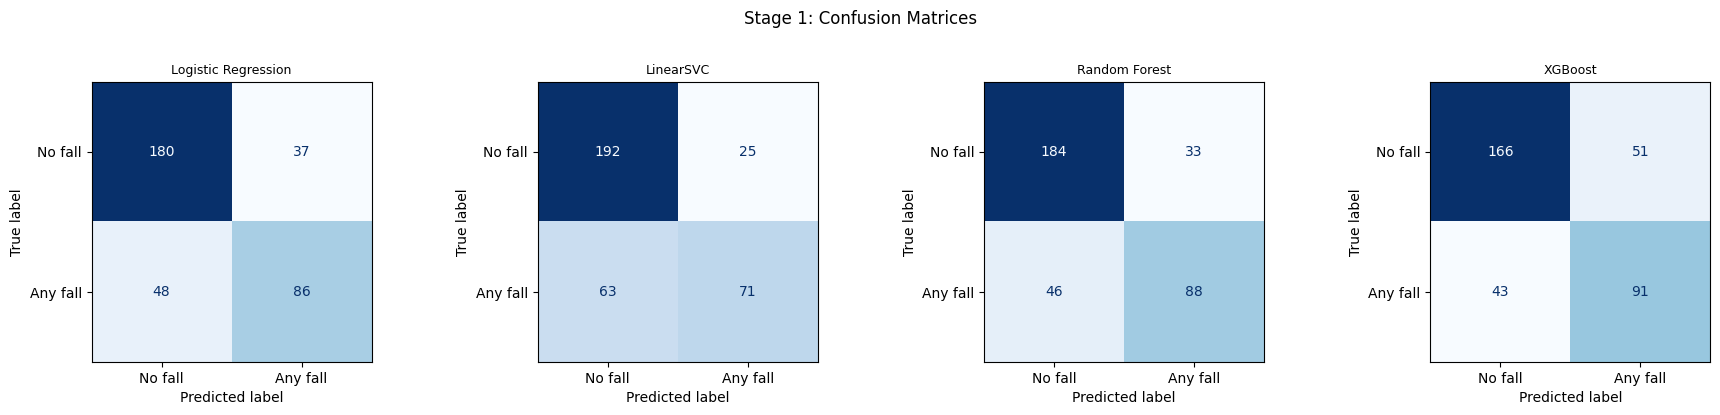

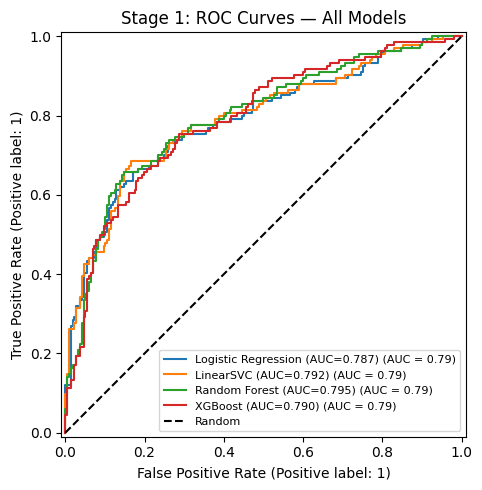

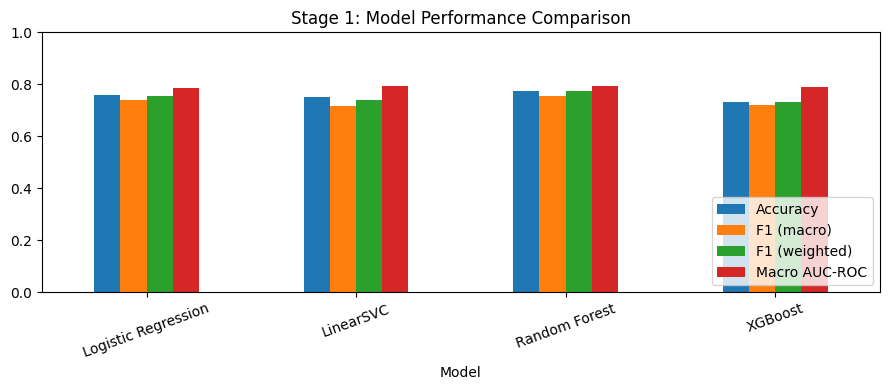

In [5]:
# ============================================================
# Stage 1: Model Comparison
# Compares Logistic Regression, LinearSVC, Random Forest,
# XGBoost, LightGBM for binary fall prediction
# (0 = no fall  vs  1 = any fall).
# Metrics: Accuracy, F1-macro, F1-weighted, Macro AUC-ROC.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay,
)

try:
    from xgboost import XGBClassifier
    _xgb_available = True
except ImportError:
    print("WARNING: xgboost not installed. Install with: pip install xgboost")
    _xgb_available = False

try:
    from lightgbm import LGBMClassifier
    _lgbm_available = True
except ImportError:
    print("WARNING: lightgbm not installed. Install with: pip install lightgbm")
    _lgbm_available = False

cv_s1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --------------------------------------------------
# Candidate models + hyperparameter grids
# --------------------------------------------------
s1_candidates = [
    (
        "Logistic Regression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        ]),
        {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
         "clf__solver": ["lbfgs", "liblinear"]},
    ),
    (
        "LinearSVC",
        CalibratedClassifierCV(
            Pipeline([
                ("scaler", StandardScaler()),
                ("clf", LinearSVC(class_weight="balanced", random_state=42, dual=False)),
            ]),
            method="sigmoid", cv=5,
        ),
        {"estimator__clf__C": [0.01, 0.1, 1, 10, 100]},
    ),
    (
        "Random Forest",
        RandomForestClassifier(class_weight={0: 1, 1: 2}, random_state=42),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [4, 6, 8, 10],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", 0.3, 0.5],
        },
    ),
]

if _xgb_available:
    s1_candidates.append((
        "XGBoost",
        XGBClassifier(
            scale_pos_weight=2,
            eval_metric="logloss",
            random_state=42,
            verbosity=0,
        ),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1, 0.2],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
        },
    ))

if _lgbm_available:
    s1_candidates.append((
        "LightGBM",
        LGBMClassifier(
            class_weight={0: 1, 1: 2},
            random_state=42,
            verbosity=-1,
        ),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7, -1],
            "learning_rate": [0.05, 0.1, 0.2],
            "num_leaves": [31, 63, 127],
            "min_child_samples": [10, 20, 30],
        },
    ))

# --------------------------------------------------
# Train and evaluate each model
# --------------------------------------------------
results_s1 = []
best_s1_models = {}

for name, estimator, param_grid in s1_candidates:
    print(f"Tuning {name}...")
    gs = GridSearchCV(
        estimator,
        param_grid,
        cv=cv_s1,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=0,
    )
    gs.fit(X_train, y_train_s1)
    best_model = gs.best_estimator_
    best_s1_models[name] = best_model
    print(f"  Best params: {gs.best_params_}")

    y_pred  = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    results_s1.append({
        "Model":         name,
        "Accuracy":      accuracy_score(y_test_s1, y_pred),
        "F1 (macro)":    f1_score(y_test_s1, y_pred,  average="macro"),
        "F1 (weighted)": f1_score(y_test_s1, y_pred,  average="weighted"),
        "Macro AUC-ROC": roc_auc_score(y_test_s1, y_proba),
        "Best Params":   str(gs.best_params_),
    })

# --------------------------------------------------
# Summary comparison table
# --------------------------------------------------
results_s1_df = pd.DataFrame(results_s1).set_index("Model")
metric_cols = ["Accuracy", "F1 (macro)", "F1 (weighted)", "Macro AUC-ROC"]
print("\n" + "=" * 70)
print("Stage 1 Model Comparison (0 = no fall  vs  1 = any fall)")
print("=" * 70)
print(results_s1_df[metric_cols].to_string(float_format="{:.4f}".format))

print("\nBest model per metric:")
for col in metric_cols:
    best_name = results_s1_df[col].idxmax()
    best_val  = results_s1_df[col].max()
    print(f"  {col:<20}: {best_name} ({best_val:.4f})")

# --------------------------------------------------
# Detailed classification reports
# --------------------------------------------------
for name, model in best_s1_models.items():
    y_pred = model.predict(X_test)
    print(f"\n=== {name} Classification Report (Stage 1) ===")
    print(classification_report(y_test_s1, y_pred,
                                target_names=["No fall (0)", "Any fall (1)"], digits=4))

# --------------------------------------------------
# Confusion matrices
# --------------------------------------------------
n_models = len(best_s1_models)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, best_s1_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test_s1, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No fall", "Any fall"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name, fontsize=9)

plt.suptitle("Stage 1: Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# ROC curves — all models on one plot
# --------------------------------------------------
fig_roc, ax_roc = plt.subplots(figsize=(7, 5))
for name, model in best_s1_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    auc_val = roc_auc_score(y_test_s1, y_proba)
    RocCurveDisplay.from_predictions(
        y_test_s1, y_proba,
        name=f"{name} (AUC={auc_val:.3f})",
        ax=ax_roc,
    )

ax_roc.plot([0, 1], [0, 1], "k--", label="Random")
ax_roc.set_title("Stage 1: ROC Curves — All Models")
ax_roc.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Bar chart: metric comparison
# --------------------------------------------------
ax_bar = results_s1_df[metric_cols].plot(
    kind="bar", figsize=(9, 4), ylim=(0, 1), rot=20,
    title="Stage 1: Model Performance Comparison",
)
ax_bar.legend(loc="lower right")
plt.tight_layout()
plt.show()


##  Stage 2: Independent Model Comparison

Stage 2 dataset: 447 patients
  Mild (1) → 0 : 319
  Moderate (2) → 1 : 128
Train: 312  |  Test: 135

Tuning Logistic Regression...
  Best params: {'clf__C': 0.01, 'clf__solver': 'lbfgs'}

Tuning LinearSVC...
  Best params: {'estimator__clf__C': 0.01}

Tuning Random Forest...


  Best params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}

Tuning XGBoost...


  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Stage 2 Independent Model Comparison
mild (class 1) = 0  |  moderate (class 2) = 1
                     Accuracy  F1 (macro)  F1 (weighted)  Macro AUC-ROC
Model                                                                  
Logistic Regression    0.7778      0.7527         0.7859         0.8454
LinearSVC              0.7630      0.6571         0.7376         0.8381
Random Forest          0.7704      0.7339         0.7755         0.8339
XGBoost                0.8148      0.7519         0.8046         0.8240

Best model per metric:
  Accuracy            : XGBoost (0.8148)
  F1 (macro)          : Logistic Regression (0.7527)
  F1 (weighted)       : XGBoost (0.8046)
  Macro AUC-ROC       : Logistic Regression (0.8454)

=== Logistic Regression Classification Report (Stage 2) ===
              precision    recall  f1-score   support

    Mild (1)     0.9024    0.7708    

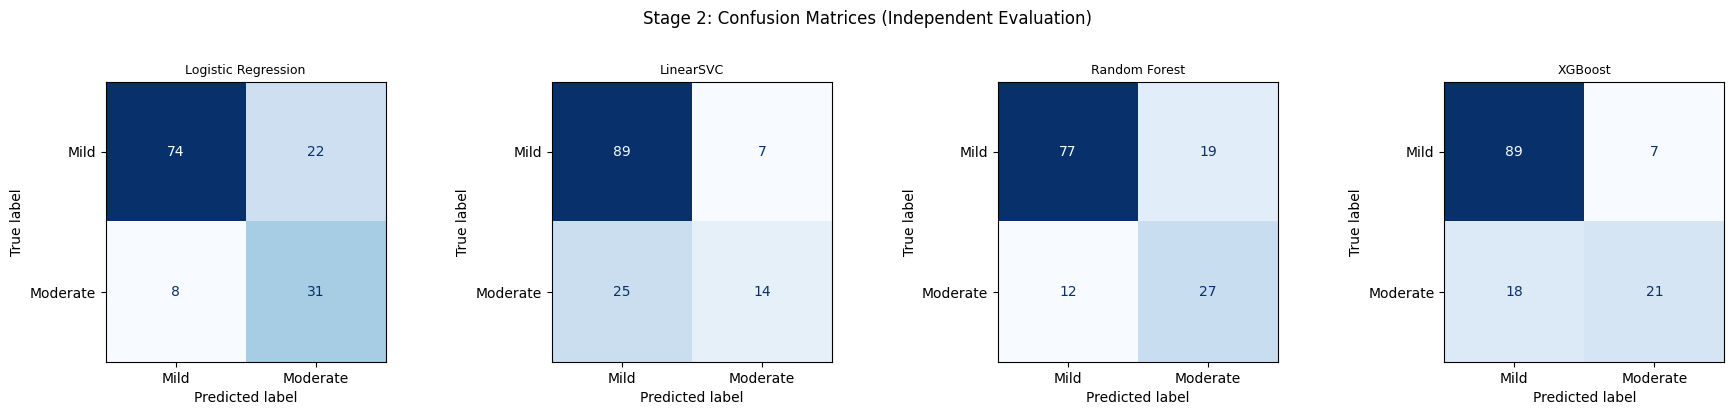

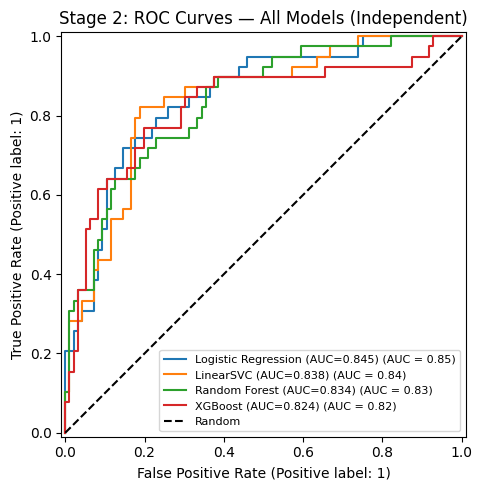

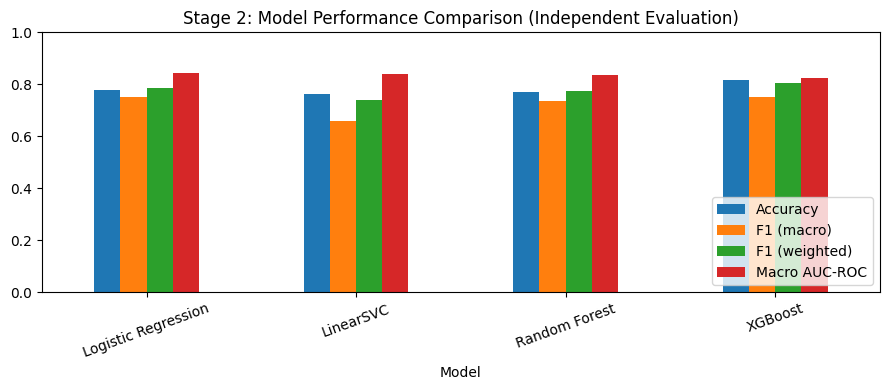

In [6]:
# ============================================================
# Stage 2: Independent Model Comparison
# Uses only class 1 (mild) and class 2 (moderate) patients
# from the original dataset — no Stage 1 routing involved.
# Binary target: mild (1) -> 0, moderate (2) -> 1
# Metrics: Accuracy, F1-macro, F1-weighted, Macro AUC-ROC.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay,
)

try:
    from xgboost import XGBClassifier
    _xgb_available = True
except ImportError:
    print("WARNING: xgboost not installed. Install with: pip install xgboost")
    _xgb_available = False

try:
    from lightgbm import LGBMClassifier
    _lgbm_available = True
except ImportError:
    print("WARNING: lightgbm not installed. Install with: pip install lightgbm")
    _lgbm_available = False

# --------------------------------------------------
# Build Stage 2 dataset: class {1, 2} patients only
# --------------------------------------------------
cols_s2 = ['No_of_years','Age',
           'Postural instability present at dx?','Rigidity present at diagnosis?',
           'Dopaminergic therapy started for participant', 'MoCA Total Score',
           'Freezing of gait in past 36 months',
           'lightheaded after standing', 'fainted',
           'Total Depression Score', 'able_weighted_score','MDS-UPDRS Part I Score',
           'BMI','Daytime_Sleepiness', 'Urinary_Problems',
           'Gait', 'Postural_Stability', 'Hoehn_And_Yahr_Stage',
           'Postural_hypotension','MDS-UPDRS Part III Score','MDS-UPDRS PartIV score']

mask_12   = data_4['Falls not rel to freezing past 36 months'].isin([1, 2])
X_s2_full = data_4.loc[mask_12, cols_s2]
Y_s2_full = (data_4.loc[mask_12, 'Falls not rel to freezing past 36 months'] == 2).astype(int)

print(f"Stage 2 dataset: {len(X_s2_full)} patients")
print(f"  Mild (1) → 0 : {(Y_s2_full == 0).sum()}")
print(f"  Moderate (2) → 1 : {(Y_s2_full == 1).sum()}")

# Fresh 70/30 stratified split
X_train_s2, X_test_s2, y_train_s2_ind, y_test_s2_ind = train_test_split(
    X_s2_full, Y_s2_full, test_size=0.3, random_state=42, stratify=Y_s2_full
)
print(f"Train: {len(X_train_s2)}  |  Test: {len(X_test_s2)}")

cv_s2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --------------------------------------------------
# Candidate models + hyperparameter grids
# --------------------------------------------------
s2_candidates = [
    (
        "Logistic Regression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        ]),
        {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
         "clf__solver": ["lbfgs", "liblinear"]},
    ),
    (
        "LinearSVC",
        CalibratedClassifierCV(
            Pipeline([
                ("scaler", StandardScaler()),
                ("clf", LinearSVC(class_weight="balanced", random_state=42, dual=False)),
            ]),
            method="sigmoid", cv=5,
        ),
        {"estimator__clf__C": [0.01, 0.1, 1, 10, 100]},
    ),
    (
        "Random Forest",
        RandomForestClassifier(class_weight="balanced", random_state=42),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
        },
    ),
]

if _xgb_available:
    s2_candidates.append((
        "XGBoost",
        XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            verbosity=0,
        ),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [2, 3, 4],
            "learning_rate": [0.05, 0.1, 0.2],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
        },
    ))

if _lgbm_available:
    s2_candidates.append((
        "LightGBM",
        LGBMClassifier(
            class_weight="balanced",
            random_state=42,
            verbosity=-1,
        ),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7, -1],
            "learning_rate": [0.05, 0.1, 0.2],
            "num_leaves": [31, 63, 127],
            "min_child_samples": [10, 20, 30],
        },
    ))

# --------------------------------------------------
# Train and evaluate each model
# --------------------------------------------------
results_s2 = []
best_s2_models = {}

for name, estimator, param_grid in s2_candidates:
    print(f"\nTuning {name}...")
    gs = GridSearchCV(
        estimator,
        param_grid,
        cv=cv_s2,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=0,
    )
    gs.fit(X_train_s2, y_train_s2_ind)
    best_model = gs.best_estimator_
    best_s2_models[name] = best_model
    print(f"  Best params: {gs.best_params_}")

    y_pred  = best_model.predict(X_test_s2)
    y_proba = best_model.predict_proba(X_test_s2)[:, 1]

    results_s2.append({
        "Model":         name,
        "Accuracy":      accuracy_score(y_test_s2_ind, y_pred),
        "F1 (macro)":    f1_score(y_test_s2_ind, y_pred,  average="macro"),
        "F1 (weighted)": f1_score(y_test_s2_ind, y_pred,  average="weighted"),
        "Macro AUC-ROC": roc_auc_score(y_test_s2_ind, y_proba),
        "Best Params":   str(gs.best_params_),
    })

# --------------------------------------------------
# Summary comparison table
# --------------------------------------------------
results_s2_df = pd.DataFrame(results_s2).set_index("Model")
metric_cols = ["Accuracy", "F1 (macro)", "F1 (weighted)", "Macro AUC-ROC"]
print("\n" + "=" * 70)
print("Stage 2 Independent Model Comparison")
print("mild (class 1) = 0  |  moderate (class 2) = 1")
print("=" * 70)
print(results_s2_df[metric_cols].to_string(float_format="{:.4f}".format))

print("\nBest model per metric:")
for col in metric_cols:
    best_name = results_s2_df[col].idxmax()
    best_val  = results_s2_df[col].max()
    print(f"  {col:<20}: {best_name} ({best_val:.4f})")

# --------------------------------------------------
# Detailed classification reports
# --------------------------------------------------
for name, model in best_s2_models.items():
    y_pred = model.predict(X_test_s2)
    print(f"\n=== {name} Classification Report (Stage 2) ===")
    print(classification_report(y_test_s2_ind, y_pred,
                                target_names=["Mild (1)", "Moderate (2)"], digits=4))

# --------------------------------------------------
# Confusion matrices
# --------------------------------------------------
n_models = len(best_s2_models)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, best_s2_models.items()):
    y_pred = model.predict(X_test_s2)
    cm = confusion_matrix(y_test_s2_ind, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Mild", "Moderate"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name, fontsize=9)

plt.suptitle("Stage 2: Confusion Matrices (Independent Evaluation)", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# ROC curves — all models on one plot
# --------------------------------------------------
fig_roc, ax_roc = plt.subplots(figsize=(7, 5))
for name, model in best_s2_models.items():
    y_proba = model.predict_proba(X_test_s2)[:, 1]
    auc_val = roc_auc_score(y_test_s2_ind, y_proba)
    RocCurveDisplay.from_predictions(
        y_test_s2_ind, y_proba,
        name=f"{name} (AUC={auc_val:.3f})",
        ax=ax_roc,
    )

ax_roc.plot([0, 1], [0, 1], "k--", label="Random")
ax_roc.set_title("Stage 2: ROC Curves — All Models (Independent)")
ax_roc.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Bar chart: metric comparison
# --------------------------------------------------
ax_bar = results_s2_df[metric_cols].plot(
    kind="bar", figsize=(9, 4), ylim=(0, 1), rot=20,
    title="Stage 2: Model Performance Comparison (Independent Evaluation)",
)
ax_bar.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Full Two-Stage Pipeline — Test Set Evaluation

Best Stage 1 model : Random Forest
Best Stage 2 model : XGBoost

Stage 1 (Random Forest) trained on 817 patients.
Stage 2 (XGBoost) trained on 313 patients.

STAGE 1 RESULTS  (Random Forest)
Test set — No fall (0) vs Any fall (1)
              precision    recall  f1-score   support

 No fall (0)     0.8000    0.8479    0.8233       217
Any fall (1)     0.7273    0.6567    0.6902       134

    accuracy                         0.7749       351
   macro avg     0.7636    0.7523    0.7567       351
weighted avg     0.7722    0.7749    0.7725       351

Accuracy     : 0.7749
F1 (macro)   : 0.7567
F1 (weighted): 0.7725
Macro AUC-ROC: 0.7946


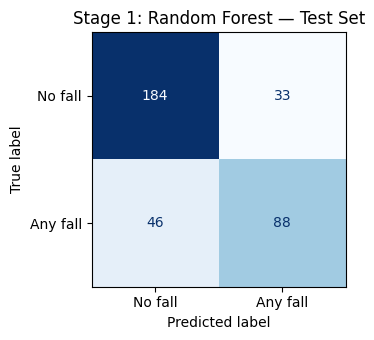


Patients routed to Stage 2: 121 / 351
  True label breakdown among routed:
    No fall (0)  : 33
    Mild (1)     : 54
    Moderate (2) : 34

STAGE 2 RESULTS  (XGBoost)
Routed patients with true class 1 or 2 — Mild (1) vs Moderate (2)
Patients evaluated: 88
              precision    recall  f1-score   support

    Mild (1)     0.7541    0.8519    0.8000        54
Moderate (2)     0.7037    0.5588    0.6230        34

    accuracy                         0.7386        88
   macro avg     0.7289    0.7053    0.7115        88
weighted avg     0.7346    0.7386    0.7316        88

Accuracy     : 0.7386
F1 (macro)   : 0.7115
F1 (weighted): 0.7316
Macro AUC-ROC: 0.7990


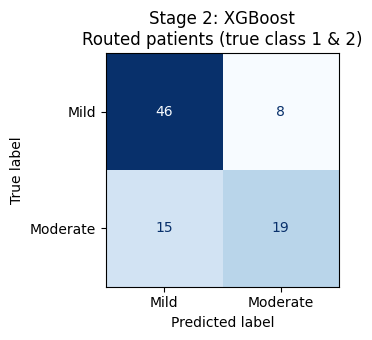


FINAL 3-CLASS PIPELINE RESULTS — Test Set
Stage 1: Random Forest  |  Stage 2: XGBoost
              precision    recall  f1-score   support

 No fall (0)     0.8000    0.8479    0.8233       217
    Mild (1)     0.5000    0.4792    0.4894        96
Moderate (2)     0.6552    0.5000    0.5672        38

    accuracy                         0.7094       351
   macro avg     0.6517    0.6090    0.6266       351
weighted avg     0.7023    0.7094    0.7042       351

Accuracy     : 0.7094
F1 (macro)   : 0.6266
F1 (weighted): 0.7042


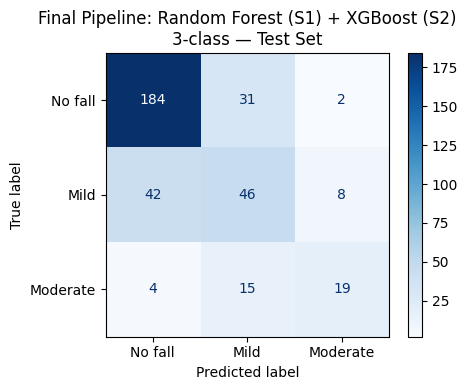

In [7]:
# ============================================================
# Full Two-Stage Pipeline — Test Set Evaluation
#
# Flow:
#   1. Train Stage 1 on (X_train, y_train_s1)
#   2. Train Stage 2 on (X_train_12, y_train_s2)
#   3. Pass X_test through Stage 1 → evaluate vs y_test_s1
#   4. Route Stage-1 fallers to Stage 2 → evaluate vs true
#      labels of those routed patients
#   5. Report final 3-class results on full test set
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

# --------------------------------------------------
# Identify best models from stage comparisons
# --------------------------------------------------
best_s1_name = results_s1_df["Accuracy"].idxmax()
best_s2_name = results_s2_df["Accuracy"].idxmax()

print(f"Best Stage 1 model : {best_s1_name}")
print(f"Best Stage 2 model : {best_s2_name}")

# --------------------------------------------------
# Train Stage 1 on training data
# --------------------------------------------------
final_s1 = best_s1_models[best_s1_name]
final_s1.fit(X_train, y_train_s1)
print(f"\nStage 1 ({best_s1_name}) trained on {len(X_train)} patients.")

# --------------------------------------------------
# Train Stage 2 on training data (class {1,2} only)
# --------------------------------------------------
final_s2 = best_s2_models[best_s2_name]
final_s2.fit(X_train_12, y_train_s2)
print(f"Stage 2 ({best_s2_name}) trained on {len(X_train_12)} patients.")

# ==================================================
# STEP 3 — Stage 1: predict on test set, evaluate
# ==================================================
pred_s1_test  = final_s1.predict(X_test)
proba_s1_test = final_s1.predict_proba(X_test)[:, 1]

print("\n" + "=" * 65)
print(f"STAGE 1 RESULTS  ({best_s1_name})")
print("Test set — No fall (0) vs Any fall (1)")
print("=" * 65)
print(classification_report(
    y_test_s1, pred_s1_test,
    target_names=["No fall (0)", "Any fall (1)"],
    digits=4,
))
print(f"Accuracy     : {accuracy_score(y_test_s1, pred_s1_test):.4f}")
print(f"F1 (macro)   : {f1_score(y_test_s1, pred_s1_test,  average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test_s1, pred_s1_test,  average='weighted'):.4f}")
print(f"Macro AUC-ROC: {roc_auc_score(y_test_s1, proba_s1_test):.4f}")

fig1, ax1 = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_s1, pred_s1_test),
    display_labels=["No fall", "Any fall"]
).plot(ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title(f"Stage 1: {best_s1_name} — Test Set")
plt.tight_layout()
plt.show()

# ==================================================
# STEP 4 — Route fallers to Stage 2, evaluate
# ==================================================
routed_mask   = (pred_s1_test == 1)
X_routed      = X_test.loc[routed_mask]
y_routed_true = y_test.loc[routed_mask]   # original 3-class true labels

print(f"\nPatients routed to Stage 2: {routed_mask.sum()} / {len(X_test)}")
print(f"  True label breakdown among routed:")
print(f"    No fall (0)  : {(y_routed_true == 0).sum()}")
print(f"    Mild (1)     : {(y_routed_true == 1).sum()}")
print(f"    Moderate (2) : {(y_routed_true == 2).sum()}")

# Keep only routed patients whose true label is 1 (mild) or 2 (moderate)
mask_true_12    = y_routed_true.isin([1, 2])
X_routed_12     = X_routed.loc[mask_true_12]
y_routed_true12 = y_routed_true.loc[mask_true_12]

# Stage 2 predictions on those patients
pred_s2_routed  = final_s2.predict(X_routed_12)
proba_s2_routed = final_s2.predict_proba(X_routed_12)[:, 1]

# Binary target: mild (1) → 0, moderate (2) → 1
y_routed_s2 = (y_routed_true12 == 2).astype(int)

print("\n" + "=" * 65)
print(f"STAGE 2 RESULTS  ({best_s2_name})")
print("Routed patients with true class 1 or 2 — Mild (1) vs Moderate (2)")
print(f"Patients evaluated: {mask_true_12.sum()}")
print("=" * 65)
print(classification_report(
    y_routed_s2, pred_s2_routed,
    target_names=["Mild (1)", "Moderate (2)"],
    digits=4,
))
print(f"Accuracy     : {accuracy_score(y_routed_s2, pred_s2_routed):.4f}")
print(f"F1 (macro)   : {f1_score(y_routed_s2, pred_s2_routed,  average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_routed_s2, pred_s2_routed,  average='weighted'):.4f}")
print(f"Macro AUC-ROC: {roc_auc_score(y_routed_s2, proba_s2_routed):.4f}")

fig2, ax2 = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_routed_s2, pred_s2_routed),
    display_labels=["Mild", "Moderate"]
).plot(ax=ax2, cmap="Blues", colorbar=False)
ax2.set_title(f"Stage 2: {best_s2_name}\nRouted patients (true class 1 & 2)")
plt.tight_layout()
plt.show()

# ==================================================
# STEP 5 — Final 3-class report on full test set
# ==================================================
# For final predictions: run Stage 2 on ALL routed patients
pred_s2_all  = final_s2.predict(X_routed)
y_pred_final = np.zeros(len(X_test), dtype=int)
idx_routed   = np.where(routed_mask)[0]
y_pred_final[idx_routed] = np.where(pred_s2_all == 0, 1, 2)

print("\n" + "=" * 65)
print("FINAL 3-CLASS PIPELINE RESULTS — Test Set")
print(f"Stage 1: {best_s1_name}  |  Stage 2: {best_s2_name}")
print("=" * 65)
print(classification_report(
    y_test, y_pred_final,
    target_names=["No fall (0)", "Mild (1)", "Moderate (2)"],
    digits=4,
))
print(f"Accuracy     : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"F1 (macro)   : {f1_score(y_test, y_pred_final,  average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_final,  average='weighted'):.4f}")

fig3, ax3 = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2]),
    display_labels=["No fall", "Mild", "Moderate"]
).plot(ax=ax3, cmap="Blues")
ax3.set_title(
    f"Final Pipeline: {best_s1_name} (S1) + {best_s2_name} (S2)\n"
    "3-class — Test Set"
)
plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# Export explanation artifacts
#
# Computes SHAP (model-agnostic: Stage 1 RF + Stage 2 XGBoost both
# resolve to TreeSHAP here, but any tree/linear model works),
# validates the artifact contract, runs determinism checks, and
# writes explanation_artifacts/ (plus a provenance manifest.json).
# Reuses the models and data trained in the cell above.
# ============================================================
import sys
from pathlib import Path

# Make the project root importable so `explanation` resolves regardless of
# whether the notebook runs from the project root or Revised_Modelling/.
_PROJECT_ROOT = Path.cwd()
if not (_PROJECT_ROOT / "explanation").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from explanation.export import export_explanation_artifacts

summary = export_explanation_artifacts(
    final_s1=final_s1,        # Stage 1 (Random Forest)
    final_s2=final_s2,        # Stage 2 (XGBoost)
    X_train=X_train,          # Stage 1 SHAP background
    X_test=X_test,            # test set to explain
    X_train_12=X_train_12,    # Stage 2 SHAP background (true fallers)
    patient_ids=id_test,      # PATNO aligned with X_test
    cols=cols,                # feature order on saved X_test
    dataset_name="Revised_Modelling/Modelling.csv",
    source_notebook="Revised_Modelling/Revised_Model_Results.ipynb",
)
summary

Explanation artifacts written to: /Users/nadin/Documents/Mobility_Decline_Risk_Prediction_For_PD_Patients/explanation_artifacts
  Test patients      : 351
  Routed to Stage 2  : 121
  shap_stage1 shape  : (351, 21)
  shap_stage2 shape  : (121, 21)
  Final prediction   : {'no_fall': 230, 'mild': 92, 'moderate': 29}
  Manifest           : /Users/nadin/Documents/Mobility_Decline_Risk_Prediction_For_PD_Patients/explanation_artifacts/manifest.json
SHAP determinism (recompute vs saved, expected 0):
  Stage 1: max|diff|=0.00e+00  mean|diff|=0.00e+00
  Stage 2: max|diff|=0.00e+00  mean|diff|=0.00e+00
All write-time validation and determinism checks passed.


{'out_dir': '/Users/nadin/Documents/Mobility_Decline_Risk_Prediction_For_PD_Patients/explanation_artifacts',
 'n_test': 351,
 'n_routed': 121,
 'shap_stage1_shape': (351, 21),
 'shap_stage2_shape': (121, 21),
 'final_counts': {'no_fall': 230, 'mild': 92, 'moderate': 29},
 'manifest': '/Users/nadin/Documents/Mobility_Decline_Risk_Prediction_For_PD_Patients/explanation_artifacts/manifest.json'}